# Análisis de datos — Bajo peso al nacer (SIVIGILA, Medellín)

Dataset: `sivigila_bpn.csv` — Sistema de Vigilancia en Salud Pública de Colombia, evento **BAJO PESO AL NACER**, casos notificados en Medellín entre 2011 y 2021.

Metodología: Lectura → Parseo → Depuración → Patrones/Tendencias → Gráficos → Conclusiones.

# 1. Lectura de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

RUTA = "../data/sivigila_bpn.csv"

# Primera lectura como texto: el dataset mezcla códigos, fechas con formato
# no estándar y comas decimales, así que se controla el parseo manualmente
# en vez de dejar que pandas infiera los tipos.
datos = pd.read_csv(RUTA, dtype=str, encoding="utf-8")

print(f"Filas: {datos.shape[0]}")
print(f"Columnas: {datos.shape[1]}")
datos.head()

Filas: 10187
Columnas: 19


,id,semana,edad_,uni_med_,sexo_,nombre_barrio,comuna,tipo_ss_,cod_ase_,fec_con_,ini_sin_,tip_cas_,pac_hos_,peso_nacer,talla_nacer,sem_gest,niv_edu_ma,evento,year_
0,1,41,28,1,M,Oriente,Manrique,N,"\""\""",01/01/1900,01/01/1900,4,1,2440,49,38,SD,BAJO PESO AL NACER,2011
1,2,41,17,1,F,SIN INFORMACION,SIN INFORMACION,S,EPS003,01/01/1900,01/01/1900,4,1,2490,46,37,SD,BAJO PESO AL NACER,2011
2,3,44,19,1,F,Villa del Socorro,Santa Cruz,S,EPS003,01/01/1900,01/01/1900,4,1,2290,47,37,SD,BAJO PESO AL NACER,2011
3,4,47,27,1,F,Las Independencias,San Javier,S,EPS003,01/01/1900,01/01/1900,4,1,2400,49,37,SD,BAJO PESO AL NACER,2011
4,5,47,23,1,F,Granizal,Popular,N,"\""\""",01/01/1900,01/01/1900,4,1,2240,47,38,SD,BAJO PESO AL NACER,2011


In [2]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 10187 entries, 0 to 10186
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             10187 non-null  str  
 1   semana         10187 non-null  str  
 2   edad_          10187 non-null  str  
 3   uni_med_       10187 non-null  str  
 4   sexo_          10187 non-null  str  
 5   nombre_barrio  10187 non-null  str  
 6   comuna         10187 non-null  str  
 7   tipo_ss_       10187 non-null  str  
 8   cod_ase_       10187 non-null  str  
 9   fec_con_       10187 non-null  str  
 10  ini_sin_       10187 non-null  str  
 11  tip_cas_       10187 non-null  str  
 12  pac_hos_       10187 non-null  str  
 13  peso_nacer     10187 non-null  str  
 14  talla_nacer    10187 non-null  str  
 15  sem_gest       10187 non-null  str  
 16  niv_edu_ma     10187 non-null  str  
 17  evento         10187 non-null  str  
 18  year_          10187 non-null  str  
dtypes: str(19)
memo

# 2. Parseo de datos

## 2.1 Números

`edad_`, `semana`, `year_` y `peso_nacer` son numéricos directos. `talla_nacer` mezcla enteros (`46`) con decimales en formato colombiano (`45,5`) y el sentinela `SD`, así que se normaliza antes de convertir. `sem_gest` también usa `SD` como sentinela de dato faltante.

In [3]:
df = datos.copy()

for columna in ["id", "edad_", "semana", "year_", "peso_nacer"]:
    df[columna] = pd.to_numeric(df[columna], errors="coerce")

# talla_nacer: coma decimal -> punto, y "SD" -> NaN antes de convertir
df["talla_nacer"] = (
    df["talla_nacer"]
    .replace("SD", np.nan)
    .str.replace(",", ".", regex=False)
)
df["talla_nacer"] = pd.to_numeric(df["talla_nacer"], errors="coerce")

# sem_gest: "SD" -> NaN
df["sem_gest"] = df["sem_gest"].replace("SD", np.nan)
df["sem_gest"] = pd.to_numeric(df["sem_gest"], errors="coerce")

print(df[["edad_", "semana", "year_", "peso_nacer", "talla_nacer", "sem_gest"]].dtypes)
df[["edad_", "peso_nacer", "talla_nacer", "sem_gest"]].describe()

edad_            int64
semana           int64
year_            int64
peso_nacer     float64
talla_nacer    float64
sem_gest       float64
dtype: object


,edad_,peso_nacer,talla_nacer,sem_gest
count,10187.000000,10185.000000,10185.000000,10185.000000
mean,25.572593,2313.819048,46.141915,37.654885
std,6.749109,167.324251,2.054569,0.869416
min,5.000000,900.000000,30.000000,37.000000
25%,20.000000,2240.000000,45.000000,37.000000
50%,25.000000,2360.000000,46.000000,37.000000
75%,30.000000,2440.000000,47.000000,38.000000
max,57.000000,2499.000000,55.000000,45.000000


## 2.2 Fechas

`fec_con_` (fecha de consulta) e `ini_sin_` (inicio de síntomas) usan `01/01/1900` como valor centinela para "sin fecha", en vez de dejar la celda vacía. Ese valor se convierte explícitamente a fecha faltante (`NaT`) para no arrastrar un año 1900 falso al análisis temporal.

In [4]:
SENTINELA_FECHA = "01/01/1900"

for columna in ["fec_con_", "ini_sin_"]:
    serie = df[columna].replace(SENTINELA_FECHA, np.nan)
    df[columna] = pd.to_datetime(serie, format="%d/%m/%Y", errors="coerce")

print("Fechas válidas en fec_con_:", df["fec_con_"].notna().sum(), "de", len(df))
print("Fechas válidas en ini_sin_:", df["ini_sin_"].notna().sum(), "de", len(df))

Fechas válidas en fec_con_: 10063 de 10187
Fechas válidas en ini_sin_: 6 de 10187


## 2.3 Texto y categorías

Se homogeneiza texto libre (espacios, mayúsculas) y se documentan los sentinelas de cada columna categórica: `nombre_barrio`/`comuna` usan `SIN INFORMACION`, `cod_ase_` usa `\"\"` (comillas vacías literales) para "sin asegurador registrado". Los códigos de `tipo_ss_`, `pac_hos_` y `niv_edu_ma` se mapean a etiquetas legibles, siguiendo el mismo criterio que usó el compañero de grupo con las columnas `*_LABEL` del dataset de World Bank.

In [5]:
columnas_texto = ["nombre_barrio", "comuna", "sexo_", "tipo_ss_", "cod_ase_", "niv_edu_ma"]

for columna in columnas_texto:
    df[columna] = df[columna].astype("string").str.strip()

df["nombre_barrio"] = df["nombre_barrio"].replace("SIN INFORMACION", pd.NA)
df["comuna"] = df["comuna"].replace("SIN INFORMACION", pd.NA)
df["cod_ase_"] = df["cod_ase_"].replace('\"\"', pd.NA)

MAPA_TIPO_SS = {
    "C": "Contributivo",
    "S": "Subsidiado",
    "N": "No asegurado",
    "E": "Excepción",
    "P": "Particular",
    "I": "Indeterminado",
}
MAPA_HOSPITALIZADO = {"1": "Sí", "2": "No"}
MAPA_NIVEL_EDUCATIVO = {
    "1": "Ninguno",
    "2": "Primaria",
    "3": "Secundaria",
    "4": "Técnico/Tecnológico",
    "5": "Universitario",
}

df["tipo_ss_label"] = df["tipo_ss_"].map(MAPA_TIPO_SS)
df["pac_hos_label"] = df["pac_hos_"].astype(str).map(MAPA_HOSPITALIZADO)
df["niv_edu_ma_label"] = df["niv_edu_ma"].replace("SD", pd.NA).map(MAPA_NIVEL_EDUCATIVO)

df[["tipo_ss_", "tipo_ss_label", "pac_hos_", "pac_hos_label", "niv_edu_ma", "niv_edu_ma_label"]].head()

,tipo_ss_,tipo_ss_label,pac_hos_,pac_hos_label,niv_edu_ma,niv_edu_ma_label
0,N,No asegurado,1,Sí,SD,NaN
1,S,Subsidiado,1,Sí,SD,NaN
2,S,Subsidiado,1,Sí,SD,NaN
3,S,Subsidiado,1,Sí,SD,NaN
4,N,No asegurado,1,Sí,SD,NaN


# 3. Depuración de datos

## 3.1 Auditoría mínima

In [6]:
reporte = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(1),
    "n_unicos": df.nunique(dropna=False),
})

print(reporte)
print()
print("Filas totalmente duplicadas:", df.duplicated().sum())
print("IDs duplicados:", df["id"].duplicated().sum())

                           dtype  n_faltantes  pct_faltantes  n_unicos
id                         int64            0            0.0     10187
semana                     int64            0            0.0        53
edad_                      int64            0            0.0        45
uni_med_                     str            0            0.0         1
sexo_                     string            0            0.0         2
nombre_barrio             string          338            3.3       450
comuna                    string          334            3.3        24
tipo_ss_                  string            0            0.0         6
cod_ase_                  string            0            0.0       106
fec_con_          datetime64[us]          124            1.2      3358
ini_sin_          datetime64[us]        10181           99.9         7
tip_cas_                     str            0            0.0         1
pac_hos_                     str            0            0.0         2
peso_n

## 3.2 Columnas sin información útil

`uni_med_`, `tip_cas_` y `evento` tienen un único valor en las 10187 filas (son constantes de este extracto del SIVIGILA), así que no aportan varianza al análisis y se excluyen. `ini_sin_` queda prácticamente vacía (99.9% de fechas faltantes) porque el evento *bajo peso al nacer* no tiene un "inicio de síntomas" real, así que también se excluye.

In [7]:
columnas_constantes = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
print("Columnas constantes detectadas:", columnas_constantes)

pct_faltante_ini_sin = df["ini_sin_"].isna().mean() * 100
print(f"% faltante en ini_sin_: {pct_faltante_ini_sin:.1f}%")

columnas_excluidas = columnas_constantes + ["ini_sin_", "uni_med_"]
columnas_excluidas = list(dict.fromkeys(columnas_excluidas))
df = df.drop(columns=[c for c in columnas_excluidas if c in df.columns])
print("Columnas excluidas del análisis:", columnas_excluidas)
print("Columnas restantes:", list(df.columns))

Columnas constantes detectadas: ['uni_med_', 'tip_cas_', 'evento']
% faltante en ini_sin_: 99.9%
Columnas excluidas del análisis: ['uni_med_', 'tip_cas_', 'evento', 'ini_sin_']
Columnas restantes: ['id', 'semana', 'edad_', 'sexo_', 'nombre_barrio', 'comuna', 'tipo_ss_', 'cod_ase_', 'fec_con_', 'pac_hos_', 'peso_nacer', 'talla_nacer', 'sem_gest', 'niv_edu_ma', 'year_', 'tipo_ss_label', 'pac_hos_label', 'niv_edu_ma_label']


## 3.3 Valores imposibles vs. atípicos

`edad_` (edad materna) tiene un rango real de 5 a 57 años, lo cual no es biológicamente coherente en los extremos: edades menores a 10 años son **imposibles** para una madre (probable error de digitación) y se excluyen del análisis por edad materna. Una edad de 57 es rara pero no imposible, así que se documenta como atípica sin eliminarla.

In [8]:
edad_imposible = df["edad_"] < 10
print(f"Registros con edad materna < 10 años (imposible): {edad_imposible.sum()}")
df.loc[edad_imposible, ["id", "edad_", "year_", "comuna"]]

Registros con edad materna < 10 años (imposible): 7


,id,edad_,year_,comuna
199,200,7,2012,El Poblado
402,403,5,2012,<NA>
603,604,5,2012,<NA>
2669,2670,9,2014,Villa Hermosa
4448,4449,8,2017,Doce de Octubre
5025,5026,6,2017,Popular
5026,5027,8,2017,La Candelaria


In [9]:
q1, q3 = df["edad_"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
atipicos_edad = df[(~edad_imposible) & (df["edad_"] > limite_superior)]
print(f"Límite superior IQR para edad materna: {limite_superior:.1f}")
print(f"Registros atípicos (altos) en edad materna: {len(atipicos_edad)}")
atipicos_edad[["id", "edad_", "year_", "comuna"]]

Límite superior IQR para edad materna: 45.0
Registros atípicos (altos) en edad materna: 13


,id,edad_,year_,comuna
15,16,49,2011,<NA>
417,418,46,2012,Guayabal
646,647,57,2012,Buenos Aires
880,881,49,2017,Robledo
1704,1705,47,2016,Robledo
1810,1811,46,2016,Popular
1886,1887,48,2016,Aranjuez
2027,2028,47,2017,La Candelaria
5430,5431,46,2015,Castilla
5626,5627,48,2016,San Antonio de Prado


In [10]:
# edad_ imposible se marca como faltante (no se inventa un valor); el resto del
# registro sigue siendo válido para las demás variables.
df.loc[edad_imposible, "edad_"] = np.nan
print("Valores de edad_ marcados como faltantes:", edad_imposible.sum())

Valores de edad_ marcados como faltantes: 7


## 3.4 Manejo de faltantes por columna

`niv_edu_ma` (10.6%), `comuna`/`nombre_barrio` (~3.3%) y `cod_ase_` quedan con categoría **"Sin dato"** explícita en vez de imputarse: son variables categóricas administrativas donde inventar un valor (por ejemplo, la moda) distorsionaría el análisis por comuna o nivel educativo. Solo se imputa `talla_nacer`, que es numérica continua con muy pocos faltantes.

In [11]:
faltantes_talla = df["talla_nacer"].isna().sum()
mediana_talla = df["talla_nacer"].median()
df["talla_nacer"] = df["talla_nacer"].fillna(mediana_talla)
print(f"talla_nacer: {faltantes_talla} valores imputados con la mediana ({mediana_talla} cm)")

df["niv_edu_ma_label"] = df["niv_edu_ma_label"].fillna("Sin dato")
df["comuna"] = df["comuna"].fillna("Sin información")

reporte_final = pd.DataFrame({
    "n_faltantes": df.isna().sum(),
    "pct_faltantes": (df.isna().mean() * 100).round(1),
})
reporte_final[reporte_final["n_faltantes"] > 0]

talla_nacer: 2 valores imputados con la mediana (46.0 cm)


,n_faltantes,pct_faltantes
edad_,7,0.1
nombre_barrio,338,3.3
fec_con_,124,1.2
peso_nacer,2,0.0
sem_gest,2,0.0


# 4. Patrones y tendencias

## 4.1 Evolución anual de casos (2011-2021)

In [12]:
casos_por_anio = df.groupby("year_").size()
print(casos_por_anio)
print()
print(f"Variación 2011 -> 2021: {casos_por_anio.iloc[-1] - casos_por_anio.iloc[0]:+d} casos "
      f"({(casos_por_anio.iloc[-1] / casos_por_anio.iloc[0] - 1) * 100:+.1f}%)")

year_
2011      96
2012     708
2013    1049
2014    1078
2015     983
2016    1002
2017    1057
2018    1147
2019    1054
2020     921
2021    1092
dtype: int64

Variación 2011 -> 2021: +996 casos (+1037.5%)


## 4.2 Distribución geográfica por comuna

In [13]:
casos_por_comuna = df["comuna"].value_counts().head(10)
casos_por_comuna

comuna
Manrique           858
Robledo            820
Villa Hermosa      784
Popular            768
San Javier         733
Doce de Octubre    710
Belen              644
Buenos Aires       613
Aranjuez           595
Santa Cruz         552
Name: count, dtype: Int64

## 4.3 Relación entre semanas de gestación y peso al nacer

A menor edad gestacional (mayor prematuridad), se espera un menor peso al nacer dentro de este grupo (todos los casos ya están por debajo de 2500 g, umbral de bajo peso al nacer).

In [14]:
correlacion = df[["sem_gest", "peso_nacer"]].corr().iloc[0, 1]
print(f"Correlación semanas de gestación vs. peso al nacer: {correlacion:.2f}")

df.groupby("sem_gest")["peso_nacer"].agg(["count", "mean", "median"]).round(1)

Correlación semanas de gestación vs. peso al nacer: 0.19


,count,mean,median
sem_gest,,,
37.0,5689,2283.3,2320.0
38.0,2796,2347.0,2390.0
39.0,1265,2359.0,2400.0
40.0,401,2368.8,2410.0
41.0,32,2361.9,2365.0
42.0,1,2300.0,2300.0
45.0,1,2490.0,2490.0


## 4.4 Nivel educativo de la madre

In [15]:
orden_educacion = ["Ninguno", "Primaria", "Secundaria", "Técnico/Tecnológico", "Universitario", "Sin dato"]
distribucion_educacion = df["niv_edu_ma_label"].value_counts().reindex(orden_educacion).fillna(0).astype(int)
distribucion_educacion

niv_edu_ma_label
Ninguno                 905
Primaria               5261
Secundaria             2781
Técnico/Tecnológico     143
Universitario            13
Sin dato               1084
Name: count, dtype: int64

# 5. Gráficos

## 5.1 Casos de bajo peso al nacer por año

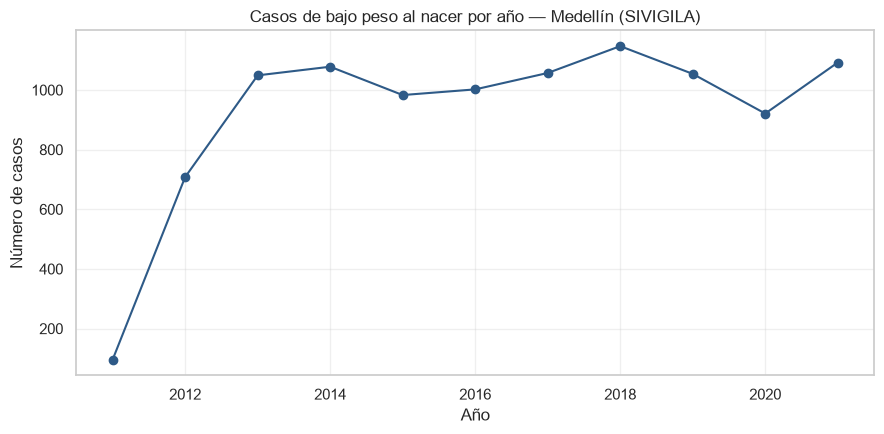

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
casos_por_anio.plot(kind="line", marker="o", ax=ax, color="#2E5A87")
ax.set_title("Casos de bajo peso al nacer por año — Medellín (SIVIGILA)")
ax.set_xlabel("Año")
ax.set_ylabel("Número de casos")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.2 Top 10 comunas con más casos

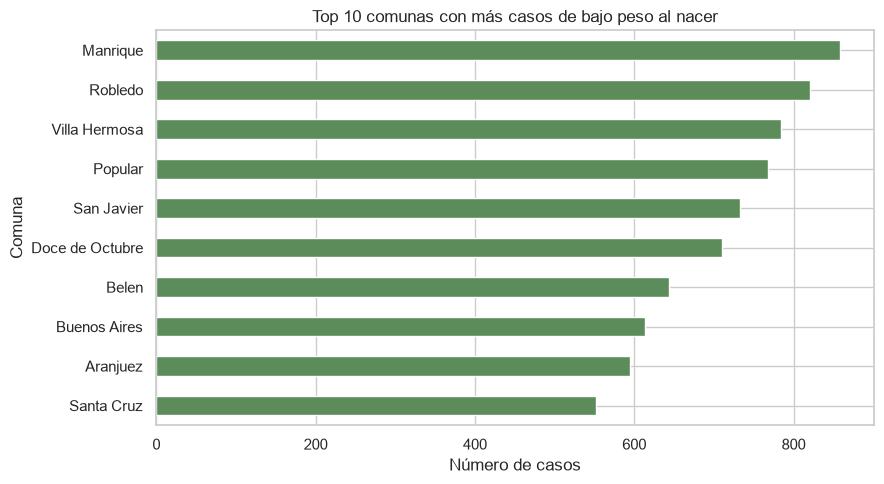

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
casos_por_comuna.sort_values().plot(kind="barh", ax=ax, color="#5B8C5A")
ax.set_title("Top 10 comunas con más casos de bajo peso al nacer")
ax.set_xlabel("Número de casos")
ax.set_ylabel("Comuna")
plt.tight_layout()
plt.show()

## 5.3 Distribución del peso al nacer

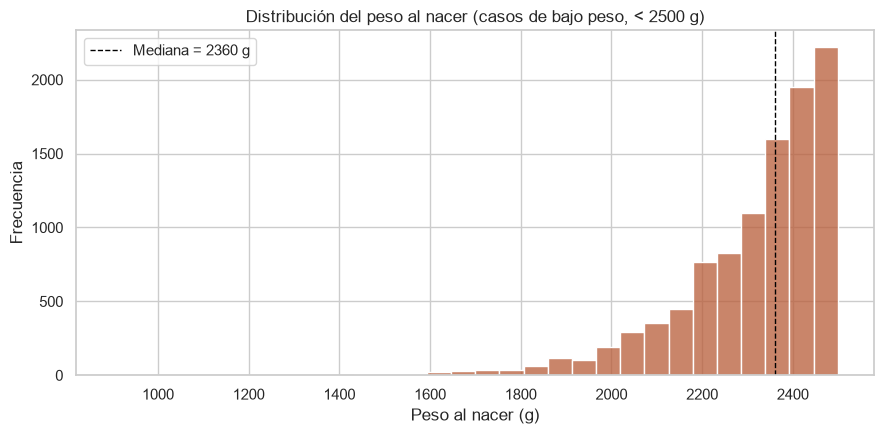

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(df["peso_nacer"], bins=30, color="#B85C38", ax=ax)
ax.axvline(df["peso_nacer"].median(), color="black", linestyle="--", linewidth=1,
           label=f"Mediana = {df['peso_nacer'].median():.0f} g")
ax.set_title("Distribución del peso al nacer (casos de bajo peso, < 2500 g)")
ax.set_xlabel("Peso al nacer (g)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

## 5.4 Semanas de gestación vs. peso al nacer

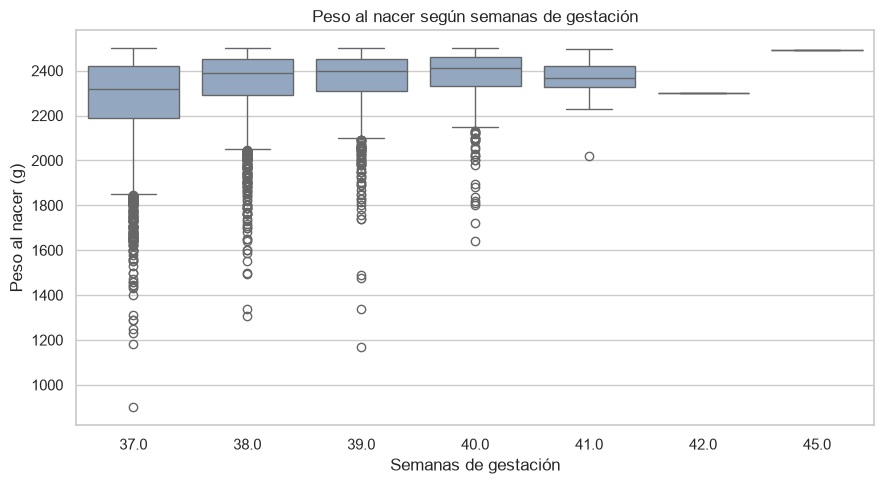

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="sem_gest", y="peso_nacer", ax=ax, color="#8CA6C9")
ax.set_title("Peso al nacer según semanas de gestación")
ax.set_xlabel("Semanas de gestación")
ax.set_ylabel("Peso al nacer (g)")
plt.tight_layout()
plt.show()

## 5.5 Nivel educativo de la madre

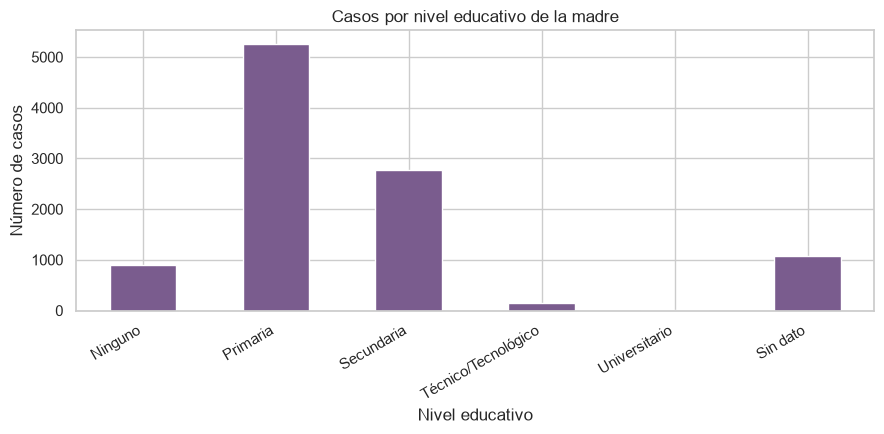

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
distribucion_educacion.plot(kind="bar", ax=ax, color="#7A5C8E")
ax.set_title("Casos por nivel educativo de la madre")
ax.set_xlabel("Nivel educativo")
ax.set_ylabel("Número de casos")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# 6. Hallazgos y conclusiones

## Sobre la calidad del dato

- **2011 está incompleto**: solo tiene 96 casos registrados frente a más de 700 en
  cada uno de los años 2012-2021. Se interpreta como un año con registro parcial en
  el sistema, no como una caída real de casos, así que se excluye como punto de
  comparación en cualquier lectura de tendencia.
- Se identificaron 7 registros con edad materna imposible (menor a 10 años,
  probable error de digitación) y se marcaron como faltantes en vez de eliminar
  la fila completa, para no perder el resto de las variables de esos casos.
- Un registro reporta 45 semanas de gestación, fuera del rango fisiológicamente
  plausible (~37-42 semanas). Al ser un único caso se documenta como posible
  error de registro sin eliminarlo, porque no afecta de forma relevante los
  estadísticos agregados.
- `ini_sin_` (fecha de inicio de síntomas) está vacía en el 99.9% de los casos,
  porque el evento *bajo peso al nacer* no tiene un inicio de síntomas real en el
  sentido en que sí lo tiene una enfermedad transmisible; por eso se excluyó del
  análisis en la sección de depuración.

## Hallazgos

1. **Concentración geográfica:** las comunas con más casos (Manrique, Robledo,
   Villa Hermosa, Popular, San Javier) coinciden con zonas de Medellín de menor
   nivel socioeconómico promedio, consistente con la asociación ya documentada
   entre determinantes sociales y bajo peso al nacer.
2. **Nivel educativo materno bajo:** el 51.6% de las madres reporta solo
   primaria y un 8.9% ningún nivel educativo, mientras que apenas un 1.5% tiene
   formación técnica o universitaria. Refuerza el patrón socioeconómico anterior.
3. **Relación débil entre semanas de gestación y peso dentro del grupo:** la
   correlación entre semanas de gestación y peso al nacer es baja (r=0.19) en
   este subconjunto. Esto no contradice la relación conocida entre prematuridad
   y bajo peso en la población general: al estar el análisis restringido solo a
   casos que ya son de bajo peso (todos por debajo de 2500 g por definición del
   evento), se pierde buena parte de la variación que explica esa relación
   (restricción de rango).
4. **Volumen relativamente estable entre 2012 y 2021:** descontando 2011 (dato
   incompleto), el número de casos anuales se mantiene entre ~700 y ~1150, sin
   una tendencia sostenida de crecimiento o disminución a lo largo de la década.
